## Requirements

In [23]:
import matplotlib.pyplot as plt
from pathlib import Path

import torch.nn
import torch.nn.functional
import torch.optim
import torch.optim.lr_scheduler
import torch.utils.data
import torchvision.datasets
import torchvision.transforms

## Data set

Define a directory to store the data.

In [2]:
data_dir = Path.cwd() / 'data'

The data should be converted to PyTorch tensors to be used for training.  It also helps to normalize the data so that the mean value of the images' pixels is 0.1307, and the standard deviation 0.3081.  This can be done using pre-defined transformers, composed into a pipeline.

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(
        (0.1307,),
        (0.3081,)
    ),
])

Now you can create a dataset for the training and the test data.

In [4]:
training_data = torchvision.datasets.MNIST(
    data_dir,
    train=True,
    download=True,
    transform=transform
)

In [5]:
training_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/gjb/Projects/Machine-learning-with-Python/source-code/pytorch/data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [6]:
test_data = torchvision.datasets.MNIST(
    data_dir,
    train=False,
    download=True,
    transform=transform
)

In [7]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /home/gjb/Projects/Machine-learning-with-Python/source-code/pytorch/data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

The data can be checked by plotting one of the images, and checking the corresponding label.

In [8]:
img, label = training_data[0]

label = 5


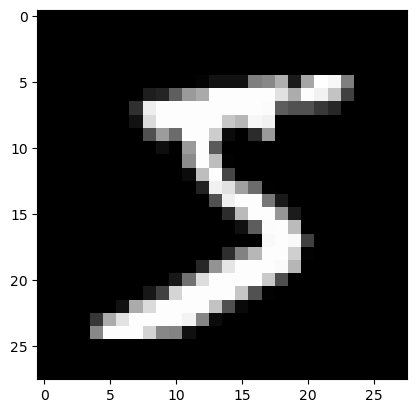

In [9]:
plt.imshow(img[0, :, :], cmap='gray');
print(f'label = {label}')

Images are 28 by 28 pixels, and have a single (grayscale) channel.

In [33]:
img.shape, img.dtype

(torch.Size([1, 28, 28]), torch.float32)

## Model

Next, you should define the model.  This is done by defining a class derived from `torch.nn.Module`.  This class has a constructor and a `forward` method.  The latter computes the output of the network, given the input.

In [10]:
class MnistNet(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, 3, 1)
        self.conv2 = torch.nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = torch.nn.Dropout(0.25)
        self.fc1 = torch.nn.Linear(9216, 128)
        self.dropout2 = torch.nn.Dropout(0.5)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.nn.functional.relu(x)
        x = self.conv2(x)
        x = torch.nn.functional.relu(x)
        x = torch.nn.functional.max_pool2d(x, 2)        
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.nn.functional.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return torch.nn.functional.log_softmax(x, dim=1)

Note that the constructor instantiates the various layers, but that the behavior of the network is determined by the `forward` method.

Tracing the data:
* input: (batch_size, 1, 28, 28)
* conv1 output: (batch_size, 32, 26, 26) since no padding is used
* conv2 output: (batch_size, 64, 24, 24), again, no padding
* max_pool output: (batch_size, 64, 12, 12)
* flatten output: (batch_size, 64*12*12) = (batch_size, 9216)
* fc1 output: (batch_size, 128)
* fc2 output: (batch_size, 10)

## Training step

In a training step, i.e., during an epoch the data is presented to the network in batches.  For each batch, the data is processed forward through the network, and the loss is computed.  Based on the latter, the gradients are computed, and the optimizer modifies the weights in the backward pass.

Note that the model is set in training mode, and that the gradients are initialized to 0 for each batch.

In [11]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = torch.nn.functional.nll_loss(output, target)
        loss.backward()
        optimizer.step() 

At the end of each epoch, the model is evaluated on the test dataset.  The model is set to evaluation mode, and the `torch.no_grad()` context manager ensures that no gradients are computed.

In [12]:
def test(model, device, test_loader, epoch):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += torch.nn.functional.nll_loss(output, target)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_size = len(test_loader.dataset)
    test_loss /= test_size
    print(f'Epoch: {epoch}')
    print(f'\tTest set loss: {test_loss:.6f}')
    print(f'\tCorrect: {correct/test_size:.4f}')

## Reproducibility

For reproducibility, it is good practice to set the seed of the pseudo-random number generators.

In [13]:
torch.manual_seed(1234);

## Data loaders

Although you already created the dataset objects, those should be wrapped in a data loader.  This ensures they are presented as batches during training, and are shuffled for each epoch.

In [14]:
loader_args = {
    'batch_size': 128,
    'num_workers': 1,
    'persistent_workers': True,
    'pin_memory': True,
    'shuffle': True,
}

In [15]:
train_loader = torch.utils.data.DataLoader(
    training_data,
    **loader_args,
)

In [16]:
test_loader = torch.utils.data.DataLoader(
    test_data,
    **loader_args,
)

## Device selection

Check whether an accelerator is available, if so, use it.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Model, optimizer and scheduler

The model can simply been instantiated by calling the class' constructor, however, it should be placed on the device where the training will be done.

In [18]:
model = MnistNet().to(device)

PyTorch defines many optimizers, in this case you can use Adadelta.  The model's parameters are passed to the optimizer, as well as a learning rate (hyperparameter).

In [19]:
optimizer = torch.optim.Adadelta(
    model.parameters(),
    lr=0.01,
)

The learning rate used by the optimizer will decay over time to improve convergence of the training.

In [20]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.9,
)

## Training

Now you are ready to begin the training.  For each epoch, a training step and and evaluation step are performed, and the scheduler modifies the learning rate.

In [21]:
for epoch in range(1, 20 + 1):
    train(
        model,
        device,
        train_loader,
        optimizer,
        epoch,
    )
    test(model, device , test_loader, epoch)
    scheduler.step()

Epoch: 1
	Test set loss: 0.002600
	Correct: 0.9099
Epoch: 2
	Test set loss: 0.001946
	Correct: 0.9294
Epoch: 3
	Test set loss: 0.001614
	Correct: 0.9408
Epoch: 4
	Test set loss: 0.001423
	Correct: 0.9497
Epoch: 5
	Test set loss: 0.001218
	Correct: 0.9562
Epoch: 6
	Test set loss: 0.001062
	Correct: 0.9605
Epoch: 7
	Test set loss: 0.000955
	Correct: 0.9637
Epoch: 8
	Test set loss: 0.000867
	Correct: 0.9665
Epoch: 9
	Test set loss: 0.000782
	Correct: 0.9697
Epoch: 10
	Test set loss: 0.000724
	Correct: 0.9720
Epoch: 11
	Test set loss: 0.000682
	Correct: 0.9732
Epoch: 12
	Test set loss: 0.000641
	Correct: 0.9748
Epoch: 13
	Test set loss: 0.000613
	Correct: 0.9767
Epoch: 14
	Test set loss: 0.000567
	Correct: 0.9779
Epoch: 15
	Test set loss: 0.000550
	Correct: 0.9785
Epoch: 16
	Test set loss: 0.000524
	Correct: 0.9803
Epoch: 17
	Test set loss: 0.000509
	Correct: 0.9809
Epoch: 18
	Test set loss: 0.000492
	Correct: 0.9807
Epoch: 19
	Test set loss: 0.000480
	Correct: 0.9821
Epoch: 20
	Test set l

The loss is still decreasing, and the accuracy increases slightly as well.  Training for more epochs would likely improve the model.

## Save model

A trained model can be saved and reused later.

In [22]:
torch.save(model.state_dict(), 'mnist_cnn.pt')

In [29]:
del model

In [30]:
model = MnistNet()
model.load_state_dict(torch.load('mnist_cnn.pt', weights_only=True))
model.to(device)

MnistNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [31]:
test(model, device, test_loader, 0)

Epoch: 0
	Test set loss: 0.000460
	Correct: 0.9823


As you can see, the loss and the accuracy of the model you just loaded are idential to the trained model after the last epoch.